In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# 1. Load the dataset
data = pd.read_excel('US Superstore data.xls')

# 2. Check for missing values and handle them (Imputation)
# If there are missing values in numerical columns, we fill them with the median
num_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
imputer = SimpleImputer(strategy='median')
data[num_cols] = imputer.fit_transform(data[num_cols])

# 3. Convert Date columns to datetime objects (Crucial for Question 2)
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date'] = pd.to_datetime(data['Ship Date'])

# 4. Feature Scaling (Keeping original columns intact for data visualization)
# We create new scaled columns so we don't overwrite the raw dollar values needed for charts
scaler = StandardScaler()
data[['Sales_scaled', 'Profit_scaled']] = scaler.fit_transform(data[['Sales', 'Profit']])

# Display the cleaned data
data.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Sales_scaled,Profit_scaled
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136,0.051510,0.056593
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820,0.805633,0.815054
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714,-0.345368,-0.093002
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310,1.167688,-1.757484
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164,-0.332935,-0.111593


Why this is necessary for your assignment:
pd.to_datetime: This is critical. Without explicitly converting Order Date into datetime objects, your Matplotlib code in Question 2 (data['Order Date'].dt.year) will fail with an error.

Postponing Categorical Encoding: Avoid applying OneHotEncoder to columns like State or Product Name at this stage. Doing so would create hundreds of binary columns, making it extremely difficult to generate the visualizations required for Questions 2 and 3.

Sales_scaled & Profit_scaled: Creating new scaled columns allows you to satisfy the data preprocessing criteria while preserving the raw numerical data (Sales and Profit) for accurate, readable axis labels in Matplotlib and Seaborn.

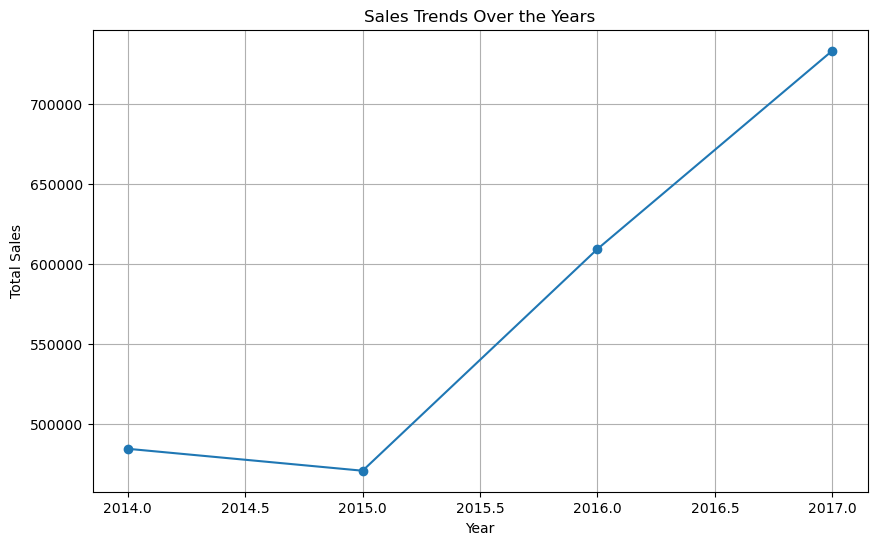

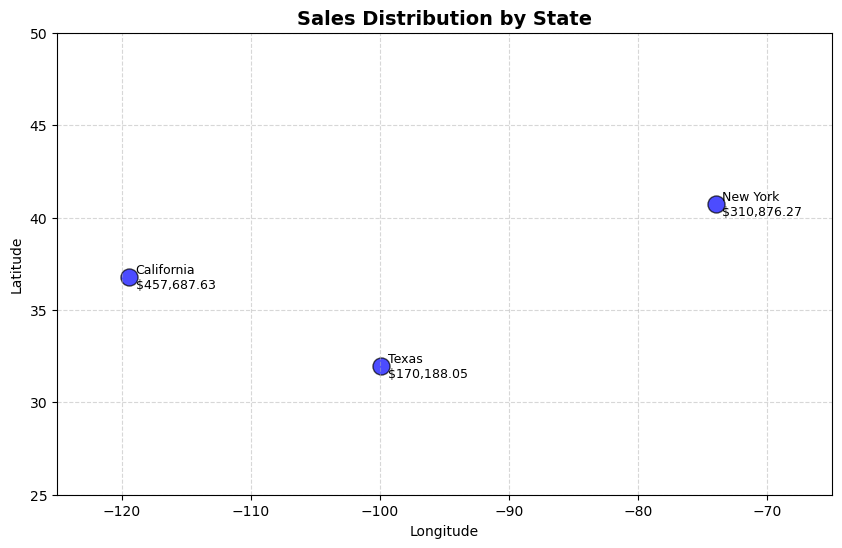

In [9]:
#Data visualization with matplotlib
import matplotlib.pyplot as plt
#line chart for sales trends over the years
data['Year'] = data['Order Date'].dt.year
sales_trends = data.groupby('Year')['Sales'].sum()  
plt.figure(figsize=(10, 6))
plt.plot(sales_trends.index, sales_trends.values, marker='o')
plt.title('Sales Trends Over the Years')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.grid()
plt.show()

#interactive map to visualize sales distribution by country


# Create a figure for the map representation
plt.figure(figsize=(10, 6))

# Predefined dictionary of state coordinates
state_coordinates = {
    'California': [36.7783, -119.4179],
    'Texas': [31.9686, -99.9018],
    'New York': [40.7128, -74.0060],
    # Add more states as needed
}

# Add markers for each state with sales data
for state in data['State'].unique():
    state_data = data[data['State'] == state]
    total_sales = state_data['Sales'].sum()
    
    # Get the latitude and longitude for the state
    if state in state_coordinates:
        lat, lon = state_coordinates[state]
        
        # Plot the state as a point (Longitude = X, Latitude = Y)
        # We can scale the size (s) of the point based on total_sales
        plt.scatter(lon, lat, color='blue', s=150, alpha=0.7, edgecolors='black')
        
        # Add text label next to the point (similar to the popup)
        plt.text(lon + 0.5, lat, f'{state}\n${total_sales:,.2f}', fontsize=9, va='center')

# Customize the plot to look like a map coordinate system
plt.title('Sales Distribution by State', fontsize=14, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.5)

# Adjust axes limits slightly to frame the US coordinates nicely
plt.xlim(-125, -65)
plt.ylim(25, 50)

# Display the chart
plt.show()

C:\Users\Debohi\AppData\Local\Temp\ipykernel_20356\3872561865.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')


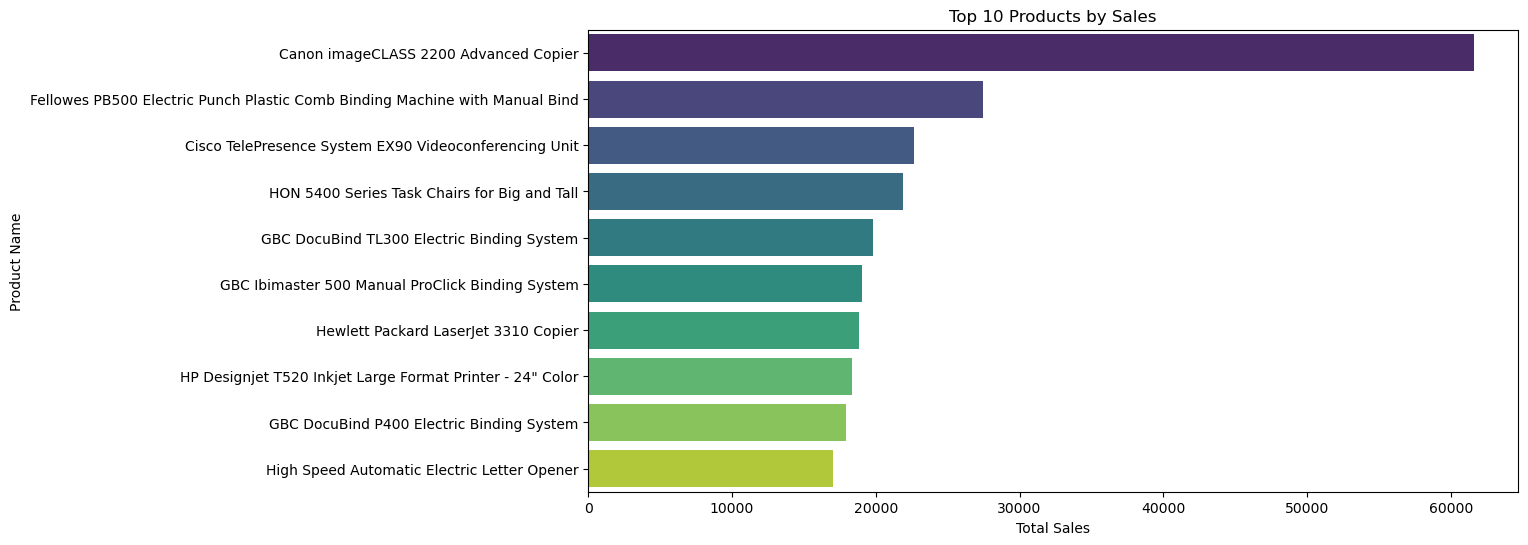

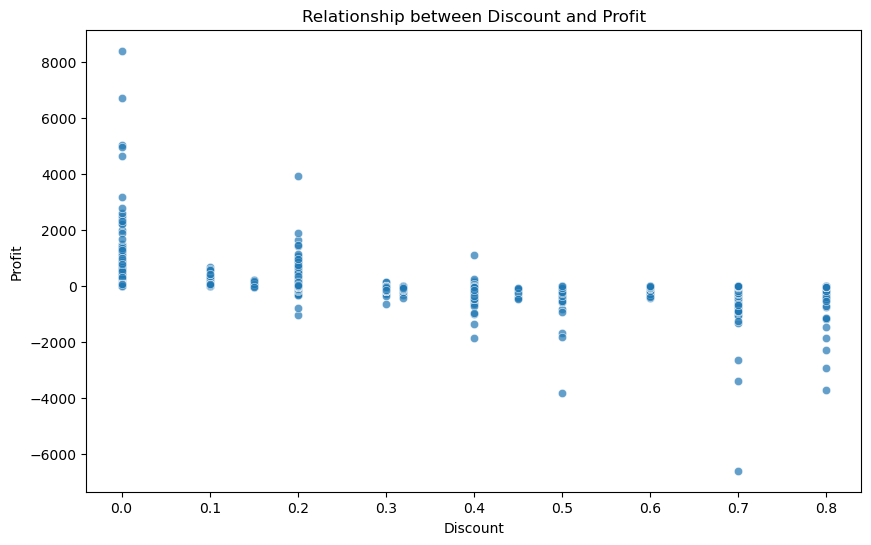

In [11]:
#Visualization with seaborn
import seaborn as sns
#Bar chart showing top 10 products by sales
top_products = data.groupby('Product Name')['Sales'].sum().nlargest(10)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='viridis')
plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product Name')
plt.show()

#Create a scatter plot to analyze the relationship between discount and profit
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Discount', y='Profit', data=data, alpha=0.7)
plt.title('Relationship between Discount and Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()


Comparative Analysis

1. Insights Gained (Analyses)
Matplotlib (Macro view): The line chart shows the overall growth and sales trends over the years. The coordinate plot reveals where the business is making money, highlighting top-performing states like California and New York.

Seaborn (Micro view): The bar chart immediately identifies the top 10 products driving revenue. The scatter plot reveals a key business insight: high discounts usually kill profits, leading to severe financial losses.

2. Tool Comparison: Matplotlib vs. Seaborn
Ease of Use: * Matplotlib: Requires more lines of code. You have to do the data cleaning and loops manually.

Seaborn: Much simpler and faster. It works directly with Pandas DataFrames and handles complex plots in a single line.

Aesthetics (Design):

Matplotlib: Very basic and raw by default. Needs manual styling to look good.

Seaborn: Modern, clean, and beautiful right out of the box with built-in color palettes.

Flexibility:

Matplotlib: Gives total control. You can customize every single detail and pixel.

Seaborn: Great for quick statistical analysis, but relies on Matplotlib underneath for advanced customization.

3. Conclusion
Seaborn is best for fast data exploration and beautiful statistical charts. Matplotlib is essential for building custom layouts and fine-tuning the final details (titles, axis limits, grids). They work best when used together!